#  Language Detection

## 1.Data Loading

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib, time, warnings
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration  import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from datasets import load_dataset
import re
from collections import Counter
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

LANG_NAMES = {
    "ar":"Arabic","bg":"Bulgarian",  "de":"German","el":"Greek",
    "en":"English","es":"Spanish","fr":"French","hi":"Hindi",
    "it":"Italian","ja":"Japanese","nl":"Dutch", "pl":"Polish",
    "pt":"Portuguese","ru":"Russian","sw":"Swahili","th":"Thai",
    "tr":"Turkish","ur":"Urdu",  "vi":"Vietnamese", "zh":"Chinese"
}


## 2. EDA — Dataset Overview

In [128]:
ds=load_dataset("papluca/language-identification")
train_df=ds['train'].to_pandas()
val_df=ds["validation"].to_pandas()
test_df=ds["test"].to_pandas()

x_train,y_train=train_df["text"].tolist(), train_df["labels"].tolist()
x_val,y_val=val_df["text"].tolist(), val_df["labels"].tolist()
x_test,y_test=test_df["text"].tolist(), test_df["labels"].tolist()

classes=sorted(set(y_train))
class_names = [LANG_NAMES[c] for c in classes]
print(f"✅ Data loaded")
print(f"Train: {len(x_train):>7,} samples")
print(f"Validation : {len(x_val):>7,} samples")
print(f"Test: {len(x_test):>7,} samples")
print(f"Classes: {len(classes)} languages → {classes}")



✅ Data loaded
Train:  70,000 samples
Validation :  10,000 samples
Test:  10,000 samples
Classes: 20 languages → ['ar', 'bg', 'de', 'el', 'en', 'es', 'fr', 'hi', 'it', 'ja', 'nl', 'pl', 'pt', 'ru', 'sw', 'th', 'tr', 'ur', 'vi', 'zh']


## 3. EDA — Text Length Analysis

Text(0.5, 0.98, 'Text Length Analysis')

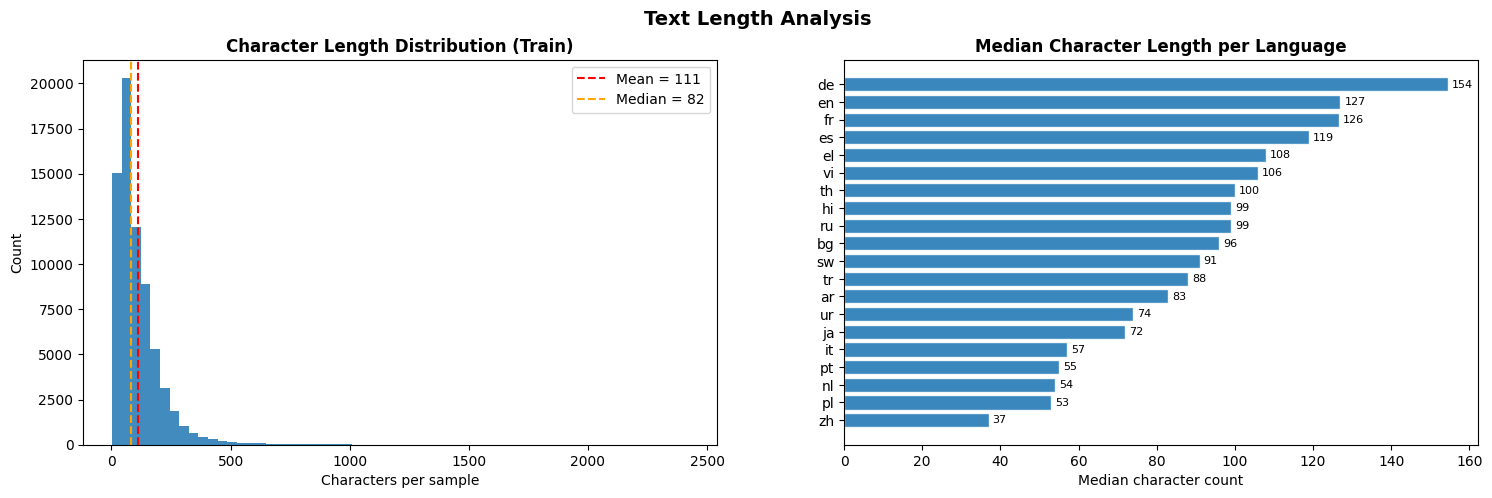

In [129]:
train_df["char_len"] = train_df["text"].astype(str).apply(len)
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
ax = axes[0]
ax.hist(train_df["char_len"],bins=60,alpha=0.85)
ax.axvline(train_df["char_len"].mean(),color="red",linestyle="--",
  label=f'Mean = {train_df["char_len"].mean():.0f}'
)
ax.axvline(train_df["char_len"].median(),color="orange",
    linestyle="--", label=f'Median = {train_df["char_len"].median():.0f}'
)
ax.set_title("Character Length Distribution (Train)",fontweight="bold")
ax.set_xlabel("Characters per sample")
ax.set_ylabel("Count")
ax.legend()

ax2 = axes[1]
med_len = (train_df.groupby("labels")["char_len"].median().sort_values())
bars = ax2.barh(med_len.index.astype(str),med_len.values,edgecolor="white",alpha=0.88)
ax2.set_title("Median Character Length per Language",fontweight="bold")

ax2.set_xlabel("Median character count")
for bar, val in zip(bars, med_len.values):
    ax2.text(bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.0f}",va="center",fontsize=8
    )
plt.suptitle("Text Length Analysis",
    fontsize=14,fontweight="bold"
)

Text(0.5, 1.0, 'Word Count per Language — Median ± StdDev')

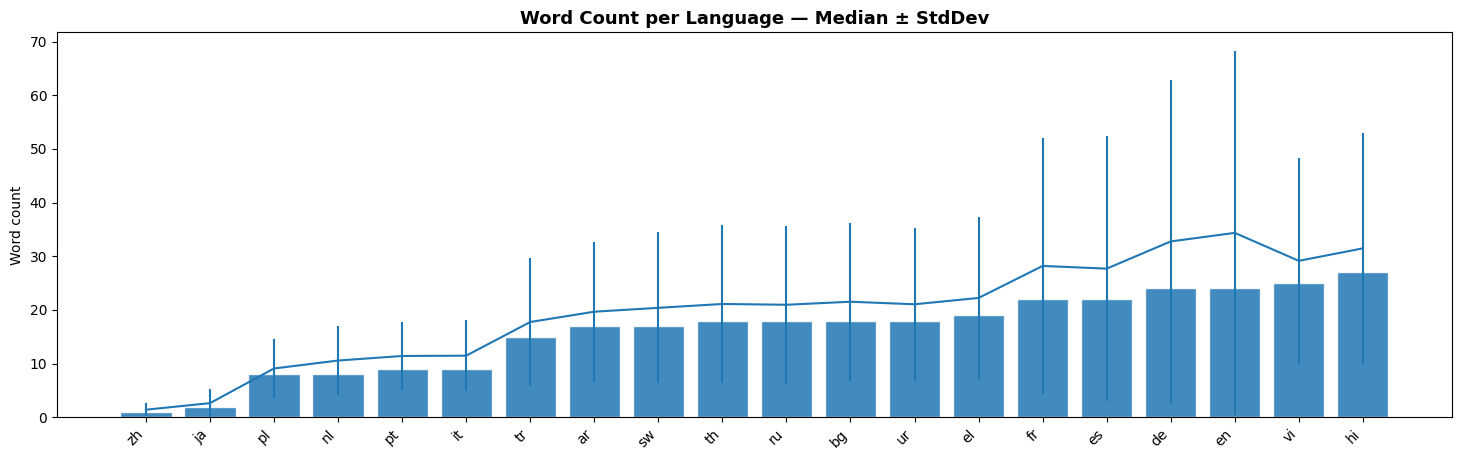

In [130]:

train_df["word_len"] = (train_df["text"].astype(str).apply(lambda x: len(x.split())))
fig, ax = plt.subplots(figsize=(18, 5))
word_stats = (train_df.groupby("labels")["word_len"].agg(["mean", "median", "std"]).sort_values("median"))
x = np.arange(len(word_stats))
ax.bar(x, word_stats["median"],edgecolor="white",
    alpha=0.85,label="Median")
ax.errorbar(x,word_stats["mean"],yerr=word_stats["std"])
ax.set_xticks(x)
ax.set_xticklabels(word_stats.index.astype(str),rotation=45,ha="right")
ax.set_ylabel("Word count")
ax.set_title("Word Count per Language — Median ± StdDev",fontweight="bold",fontsize=13)



## 4. EDA — Most Common Words per Language

Text(0.5, 0.98, 'Top 12 Most Common Words per Language (Train Set)')

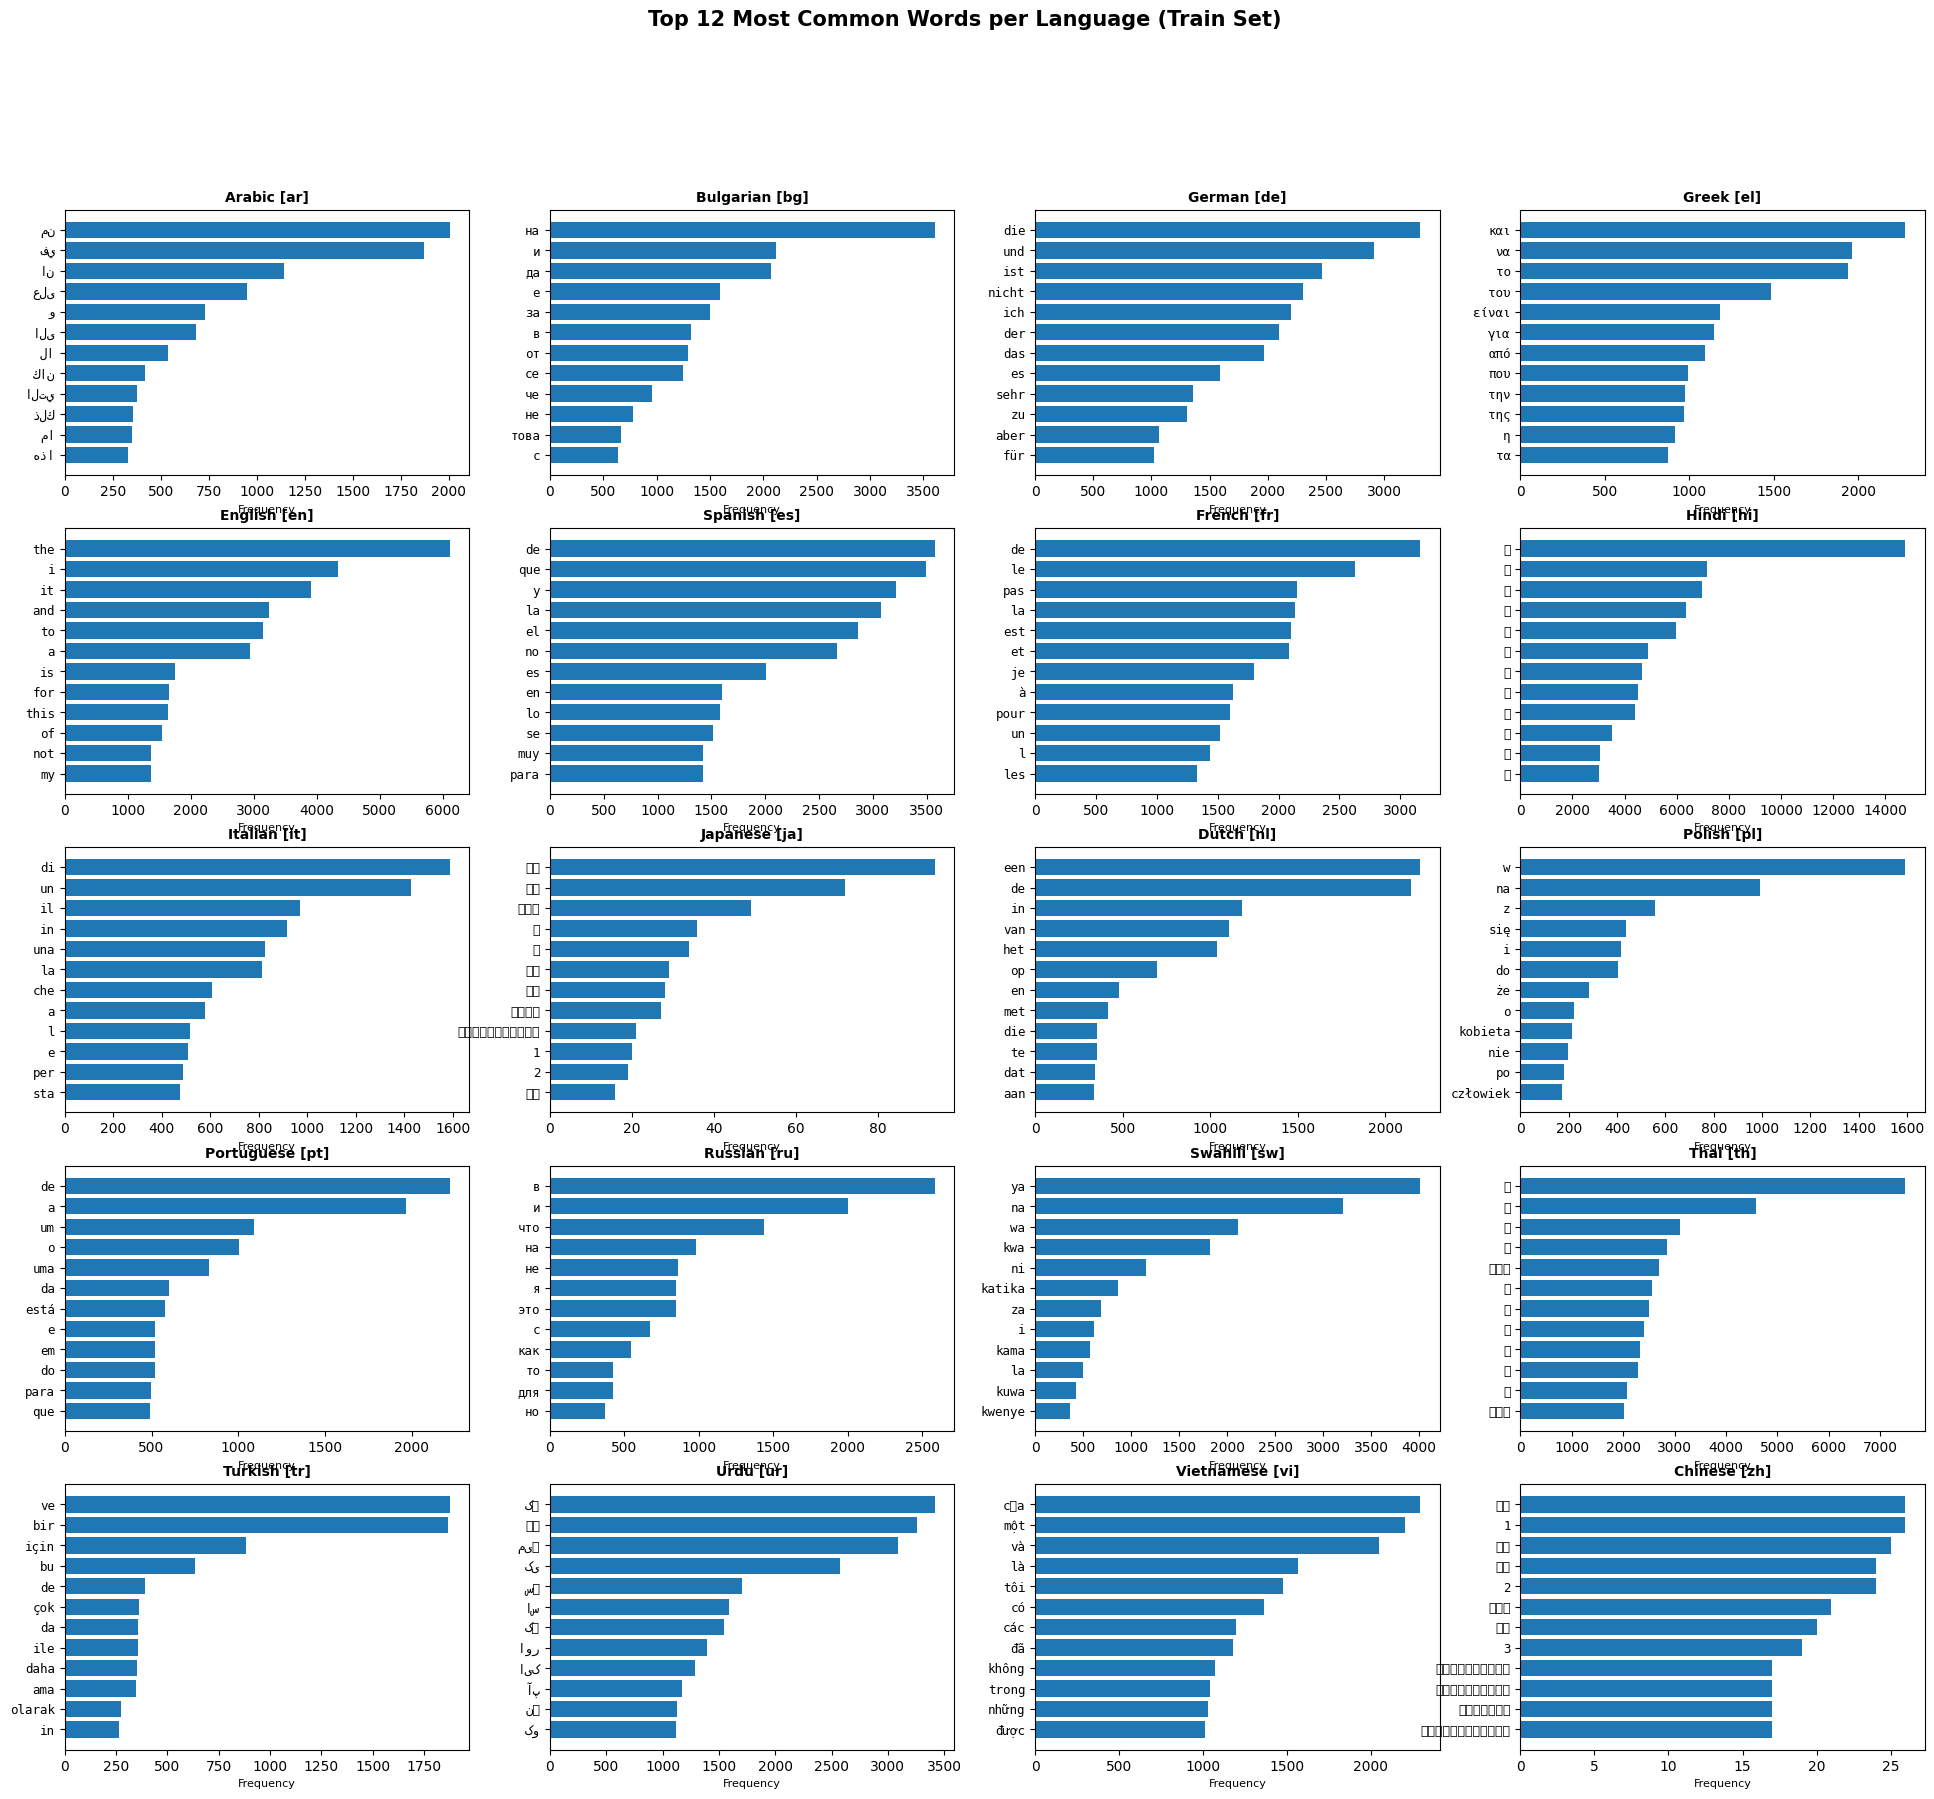

In [131]:
def get_top_words(texts, n=15):
    full_text = " ".join(map(str, texts)).lower()
    tokens = re.findall(r"\b\w+\b", full_text)
    return Counter(tokens).most_common(n)

n_cols = 4
n_rows = (len(classes) + n_cols - 1) // n_cols
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(24, n_rows * 4)
)

axes = axes.flatten()
for ax, lang in zip(axes, classes):
    texts = train_df[
        train_df["labels"] == lang
    ]["text"].tolist()
    top = get_top_words(texts, n=12)
    words = [w for w, _ in top]
    counts = [c for _, c in top]
    y_pos = range(len(words))
    ax.barh(list(y_pos),counts[::-1],)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(words[::-1],fontsize=9,fontfamily="monospace")
    ax.set_title(f"{LANG_NAMES.get(lang, lang)} [{lang}]",fontweight="bold",fontsize=10 )
    ax.set_xlabel("Frequency", fontsize=8)

for ax in axes[len(classes):]:
    ax.set_visible(False)

plt.suptitle( "Top 12 Most Common Words per Language (Train Set)",fontsize=15,fontweight="bold")

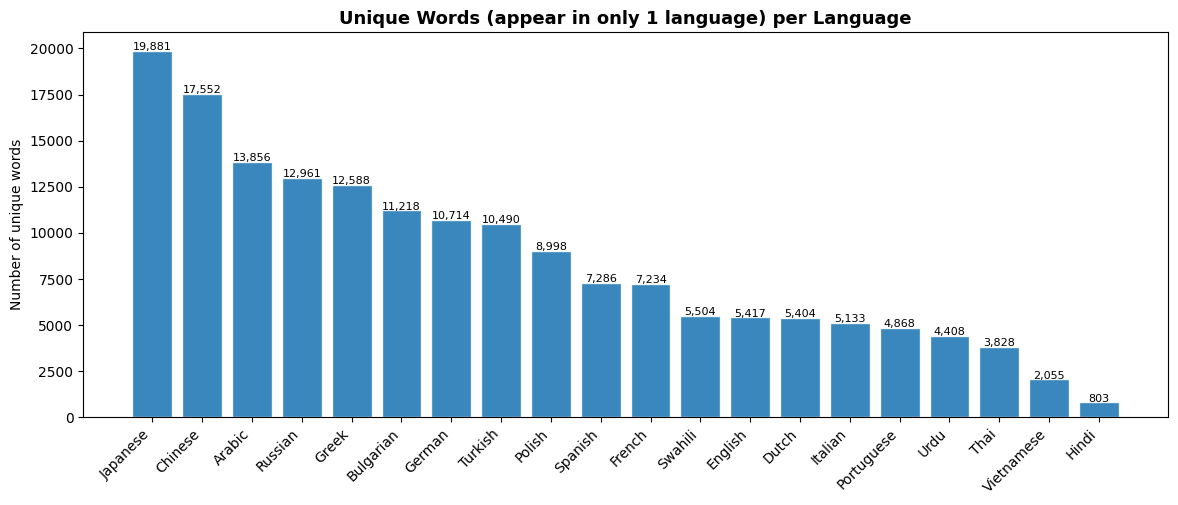

In [132]:

lang_vocabs = {}
for lang in classes:
    texts = train_df[train_df["labels"] == lang]["text"].tolist()
    tokens = set(re.findall(r"\b\w{3,}\b", " ".join(texts).lower()))
    lang_vocabs[lang] = tokens
all_words = set().union(*lang_vocabs.values())
word_lang_count = {}
for word in all_words:
    word_lang_count[word] = sum(1 for l in classes if word in lang_vocabs[l])
unique_words = {lang: [w for w in lang_vocabs[lang] if word_lang_count[w] == 1]
                for lang in classes}
unique_counts = pd.Series({LANG_NAMES[l]: len(unique_words[l]) for l in classes}).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(unique_counts.index, unique_counts.values,
              edgecolor="white", alpha=0.88)
ax.set_xticklabels(unique_counts.index, rotation=45, ha="right")
ax.set_ylabel("Number of unique words")
ax.set_title("Unique Words (appear in only 1 language) per Language", fontweight="bold", fontsize=13)
for bar, val in zip(bars, unique_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{val:,}", ha="center", fontsize=8)

In [133]:
MIN_FREQ     = 10
MIN_LANGS    = 3
word_to_langs = {}
for lang in lang_vocabs:
    all_words = ' '.join(train_df.loc[train_df['labels'] == lang, 'text'].str.lower()).split()
    counter = Counter(all_words)
    for word, freq in counter.items():
        if freq >= MIN_FREQ and word.isalpha() and len(word) > 2:
            word_to_langs.setdefault(word, set()).add(lang)
shared_words = {
    w: langs for w, langs in word_to_langs.items()
    if len(langs) >= MIN_LANGS
}
print(f"Words appearing in ≥ {MIN_LANGS} languages: {len(shared_words):,}")

shared_sorted = sorted(shared_words.items(), key=lambda x: len(x[1]), reverse=True)[:25]
print(f"\nTop 25 most cross-lingual words:")
print(f"{'Word':<20} {'# Languages':>12}  Languages")
print("-" * 70)
for word, langs in shared_sorted:
    print(f"{word:<20} {len(langs):>12}  {', '.join(sorted(langs))}")

Words appearing in ≥ 3 languages: 71

Top 25 most cross-lingual words:
Word                  # Languages  Languages
----------------------------------------------------------------------
lsc                             7  bg, el, hi, sw, th, tr, vi
the                             6  en, pl, sw, th, ur, vi
new                             6  en, it, nl, sw, tr, vi
standard                        5  en, it, nl, pl, pt
base                            5  en, es, fr, it, pt
super                           4  de, en, es, fr
amazon                          4  de, en, es, fr
was                             4  de, en, nl, sw
mal                             4  de, es, fr, tr
kind                            4  de, en, nl, sw
usb                             4  de, en, es, fr
foto                            4  de, es, it, nl
bluetooth                       4  de, en, es, fr
son                             4  en, es, fr, tr
grande                          4  es, fr, it, pt
poirot                     

In [134]:
from wordcloud import WordCloud
import matplotlib.colors as mcolors
from wordcloud import WordCloud
wc = WordCloud(
    font_path="/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc"
)
def make_color_func(hex_color):
    """Return a wordcloud color_func that shades one hue from light to dark."""
    r, g, b = mcolors.hex2color(hex_color)
    def color_func(word, font_size, position, orientation, random_state=None, **kwargs):
        lightness = max(0.25, min(0.85, 0.4 + 0.4 * (1 - font_size / 120)))
        h, s, v = mcolors.rgb_to_hsv((r, g, b))
        rgb255 = tuple(int(c * 255) for c in mcolors.hsv_to_rgb((h, s, lightness)))
        return 'rgb(%d, %d, %d)' % rgb255
    return color_func

print('✅ WordCloud ready')

✅ WordCloud ready


In [135]:
!apt-get update
!apt-get install -y fonts-noto-cjk

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 3,917 B in 1s (2,644 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-noto-cjk is already the newest version (1:20

In [136]:
!apt-get update
!apt-get install -y fonts-noto fonts-noto-cjk fonts-noto-extra

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 3,917 B in 2s (2,351 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-noto-cjk is already the newest version (1:20

In [137]:
!pip install arabic-reshaper python-bidi

## 5. EDA — Word Clouds per Language

 WordCloud ready


Text(0.5, 1.01, 'Word Clouds — Most Frequent Words per Language (Train Set)')

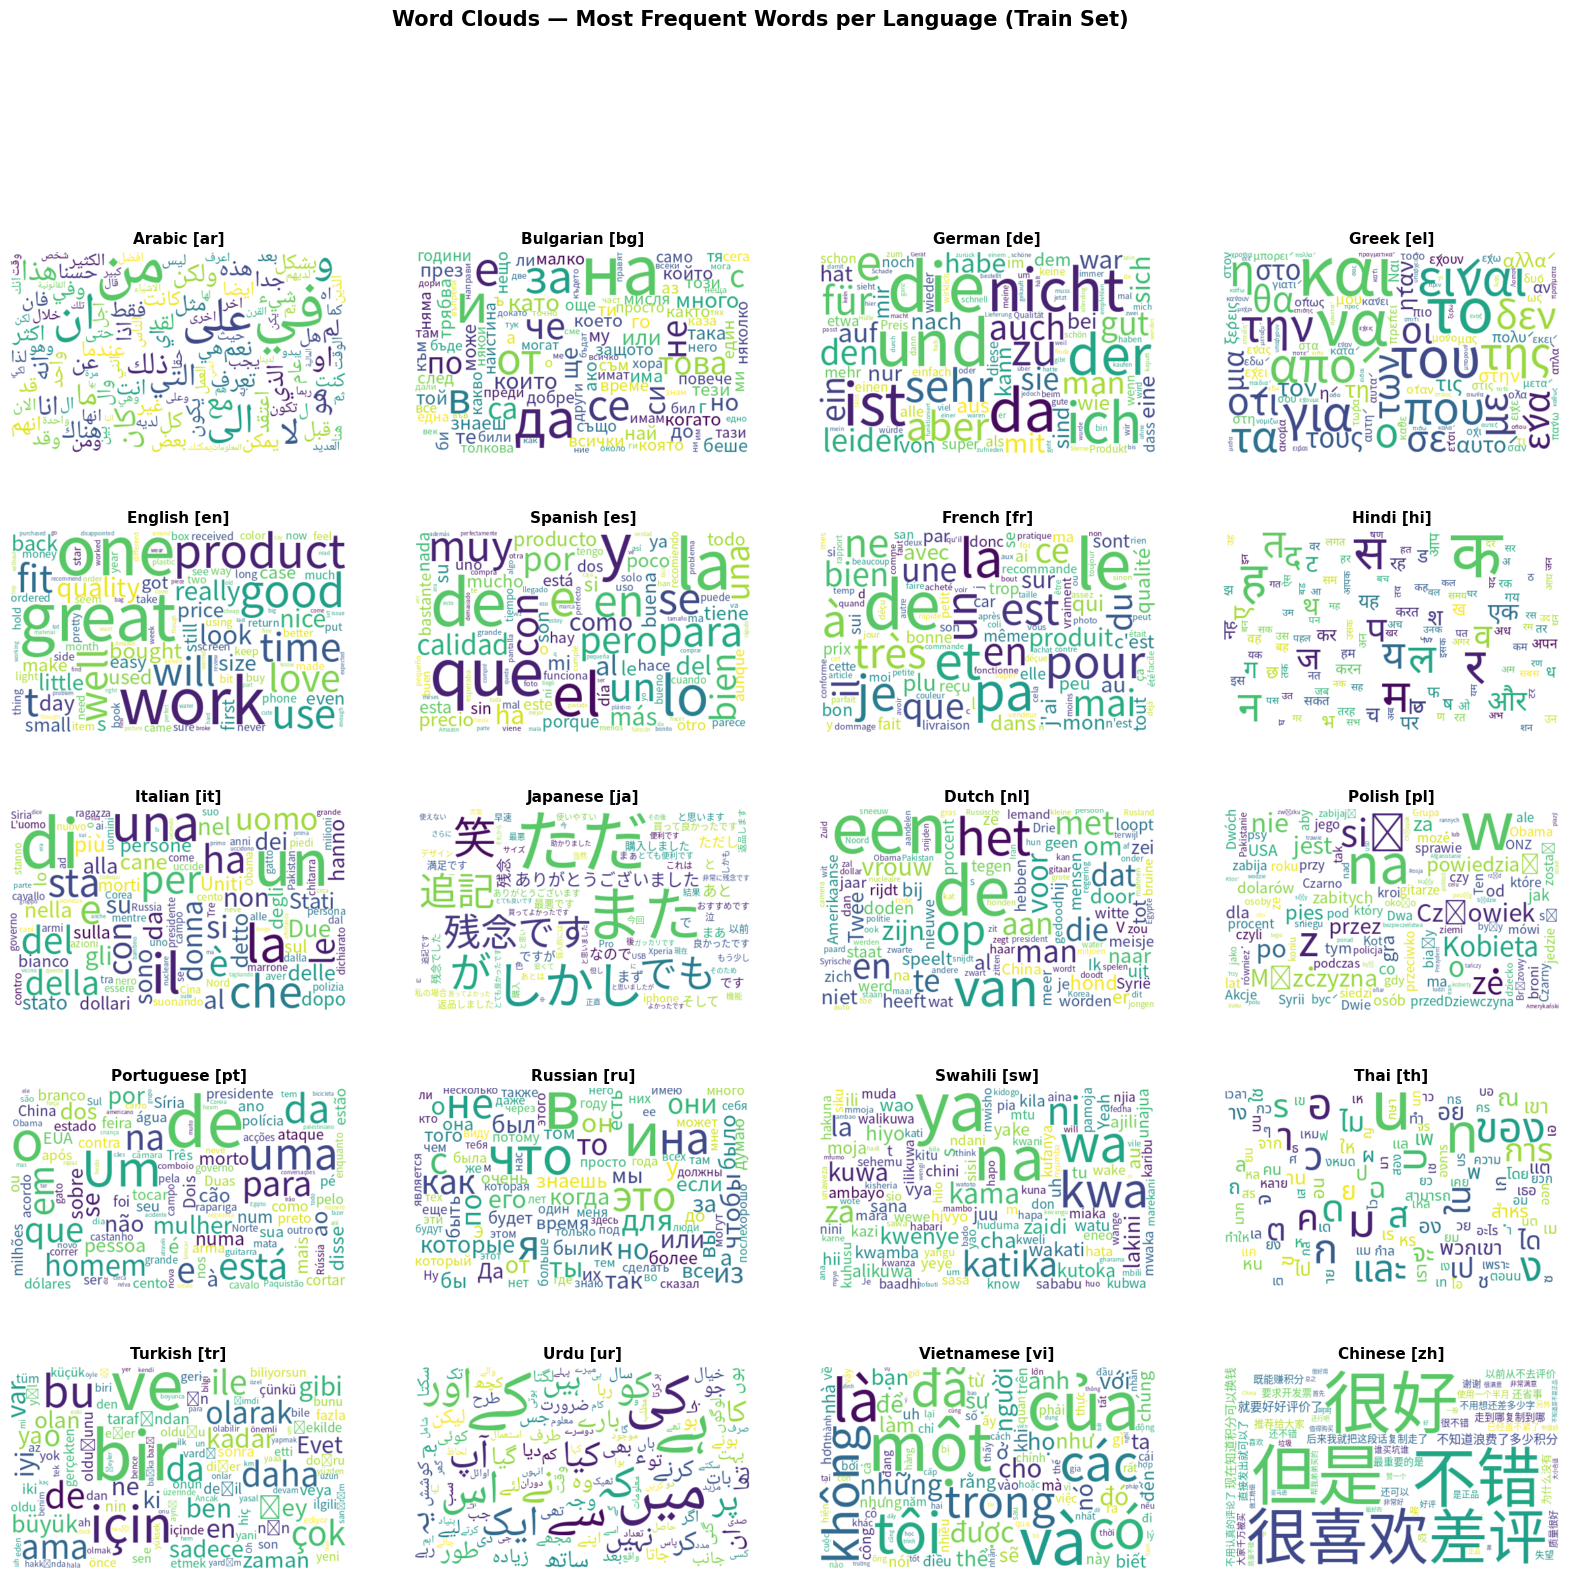

In [138]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
font_map = {
    "zh": "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "ja": "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "ko": "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "ar": "/usr/share/fonts/truetype/noto/NotoNaskhArabic-Regular.ttf",
    "ur": "/usr/share/fonts/truetype/noto/NotoNaskhArabic-Regular.ttf",
    "hi": "/usr/share/fonts/truetype/noto/NotoSansDevanagari-Regular.ttf",
    "th": "/usr/share/fonts/truetype/noto/NotoSansThai-Regular.ttf",
}
def make_color_func(hex_color):
    r, g, b = mcolors.hex2color(hex_color)
    def color_func(word, font_size, position,orientation, random_state=None, **kwargs):
        lightness = max(0.25,min(0.85, 0.4 + 0.4 * (1 - font_size / 120)))
        h, s, v = mcolors.rgb_to_hsv((r, g, b))
        rgb255 = tuple(
            int(c * 255)
            for c in mcolors.hsv_to_rgb((h, s, lightness))
        )

        return 'rgb(%d, %d, %d)' % rgb255
    return color_func
print(" WordCloud ready")

n_cols_wc = 4
n_rows_wc = (len(classes) + n_cols_wc - 1) // n_cols_wc
fig, axes = plt.subplots(
    n_rows_wc,
    n_cols_wc,
    figsize=(n_cols_wc * 5, n_rows_wc * 3.5)
)
axes = axes.flatten()
for ax, lang in zip(axes, classes):
    texts = train_df[train_df['labels'] == lang]['text'].astype(str).tolist()
    combined = ' '.join(texts[:5000])
    wc = WordCloud(
        width=500,
        height=300,
        background_color='white',
        max_words=120,
        prefer_horizontal=0.85,
        collocations=False,
        min_font_size=8,
        max_font_size=100,
        random_state=42,
        font_path=font_map.get(
            lang,
            "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
        )
    ).generate(combined)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(
        f"{LANG_NAMES[lang]} [{lang}]",
        fontweight='bold',
        fontsize=11,
        pad=6
    )
for ax in axes[len(classes):]:
    ax.set_visible(False)
plt.suptitle(
    'Word Clouds — Most Frequent Words per Language (Train Set)',
    fontsize=15,
    fontweight='bold',
    y=1.01
)


Text(0.5, 0.98, 'Word Clouds — Hardest Latin-script Language Pairs')

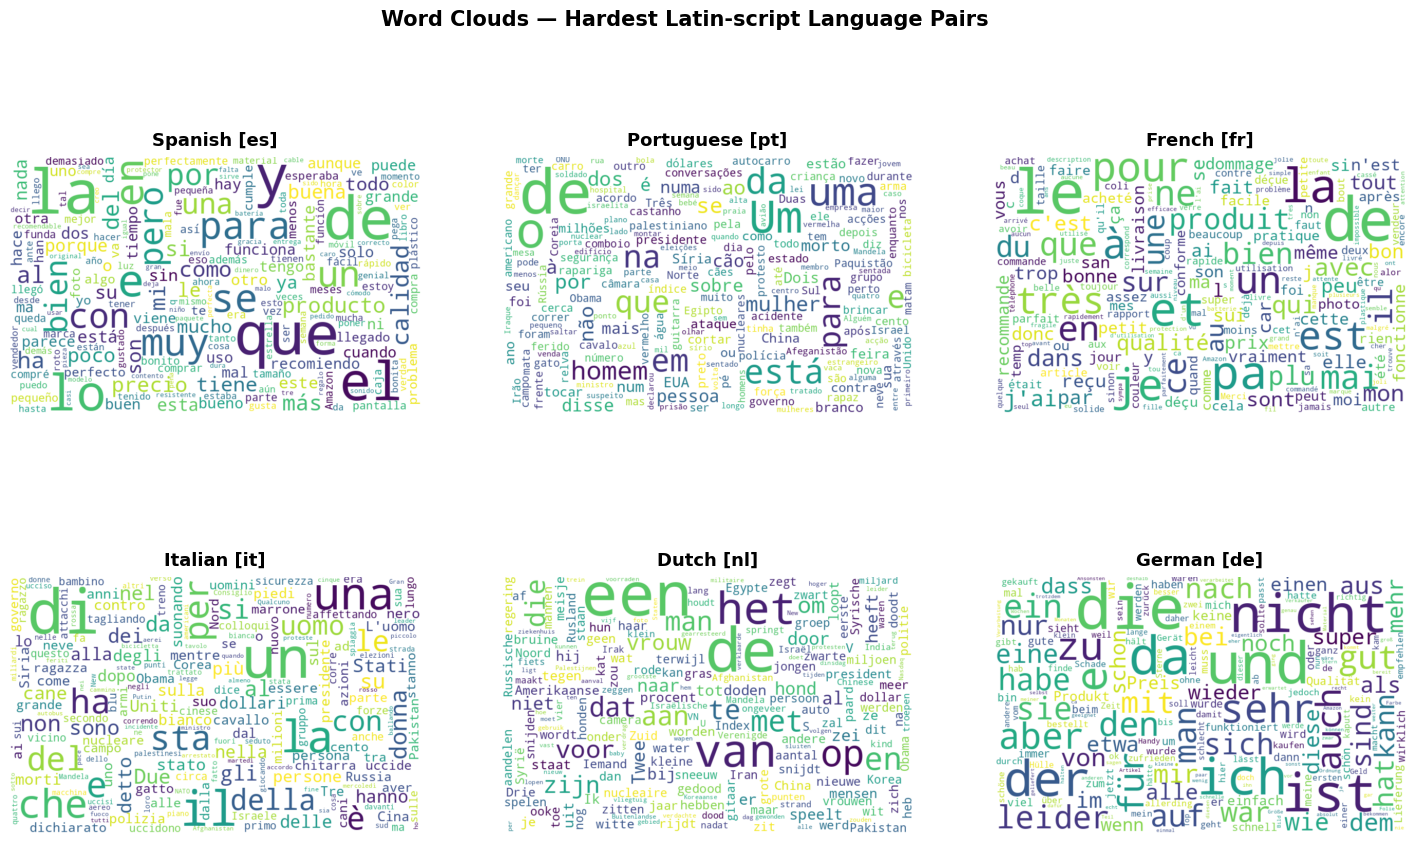

In [139]:
hard_langs = ['es', 'pt', 'fr', 'it', 'nl', 'de']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, lang in zip(axes, hard_langs):
    texts    = train_df[train_df['labels'] == lang]['text'].tolist()
    combined = ' '.join(texts)

    wc = WordCloud(
        width=800, height=500,
        background_color='white',
        max_words=200,
        prefer_horizontal=0.80,
        collocations=False,
        min_font_size=9, max_font_size=120,
        random_state=42,
    ).generate(combined)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f"{LANG_NAMES[lang]} [{lang}]", fontweight='bold', fontsize=13, pad=8)

plt.suptitle('Word Clouds — Hardest Latin-script Language Pairs',
             fontsize=15, fontweight='bold')

✅ These are the words the model relies on most for discrimination.


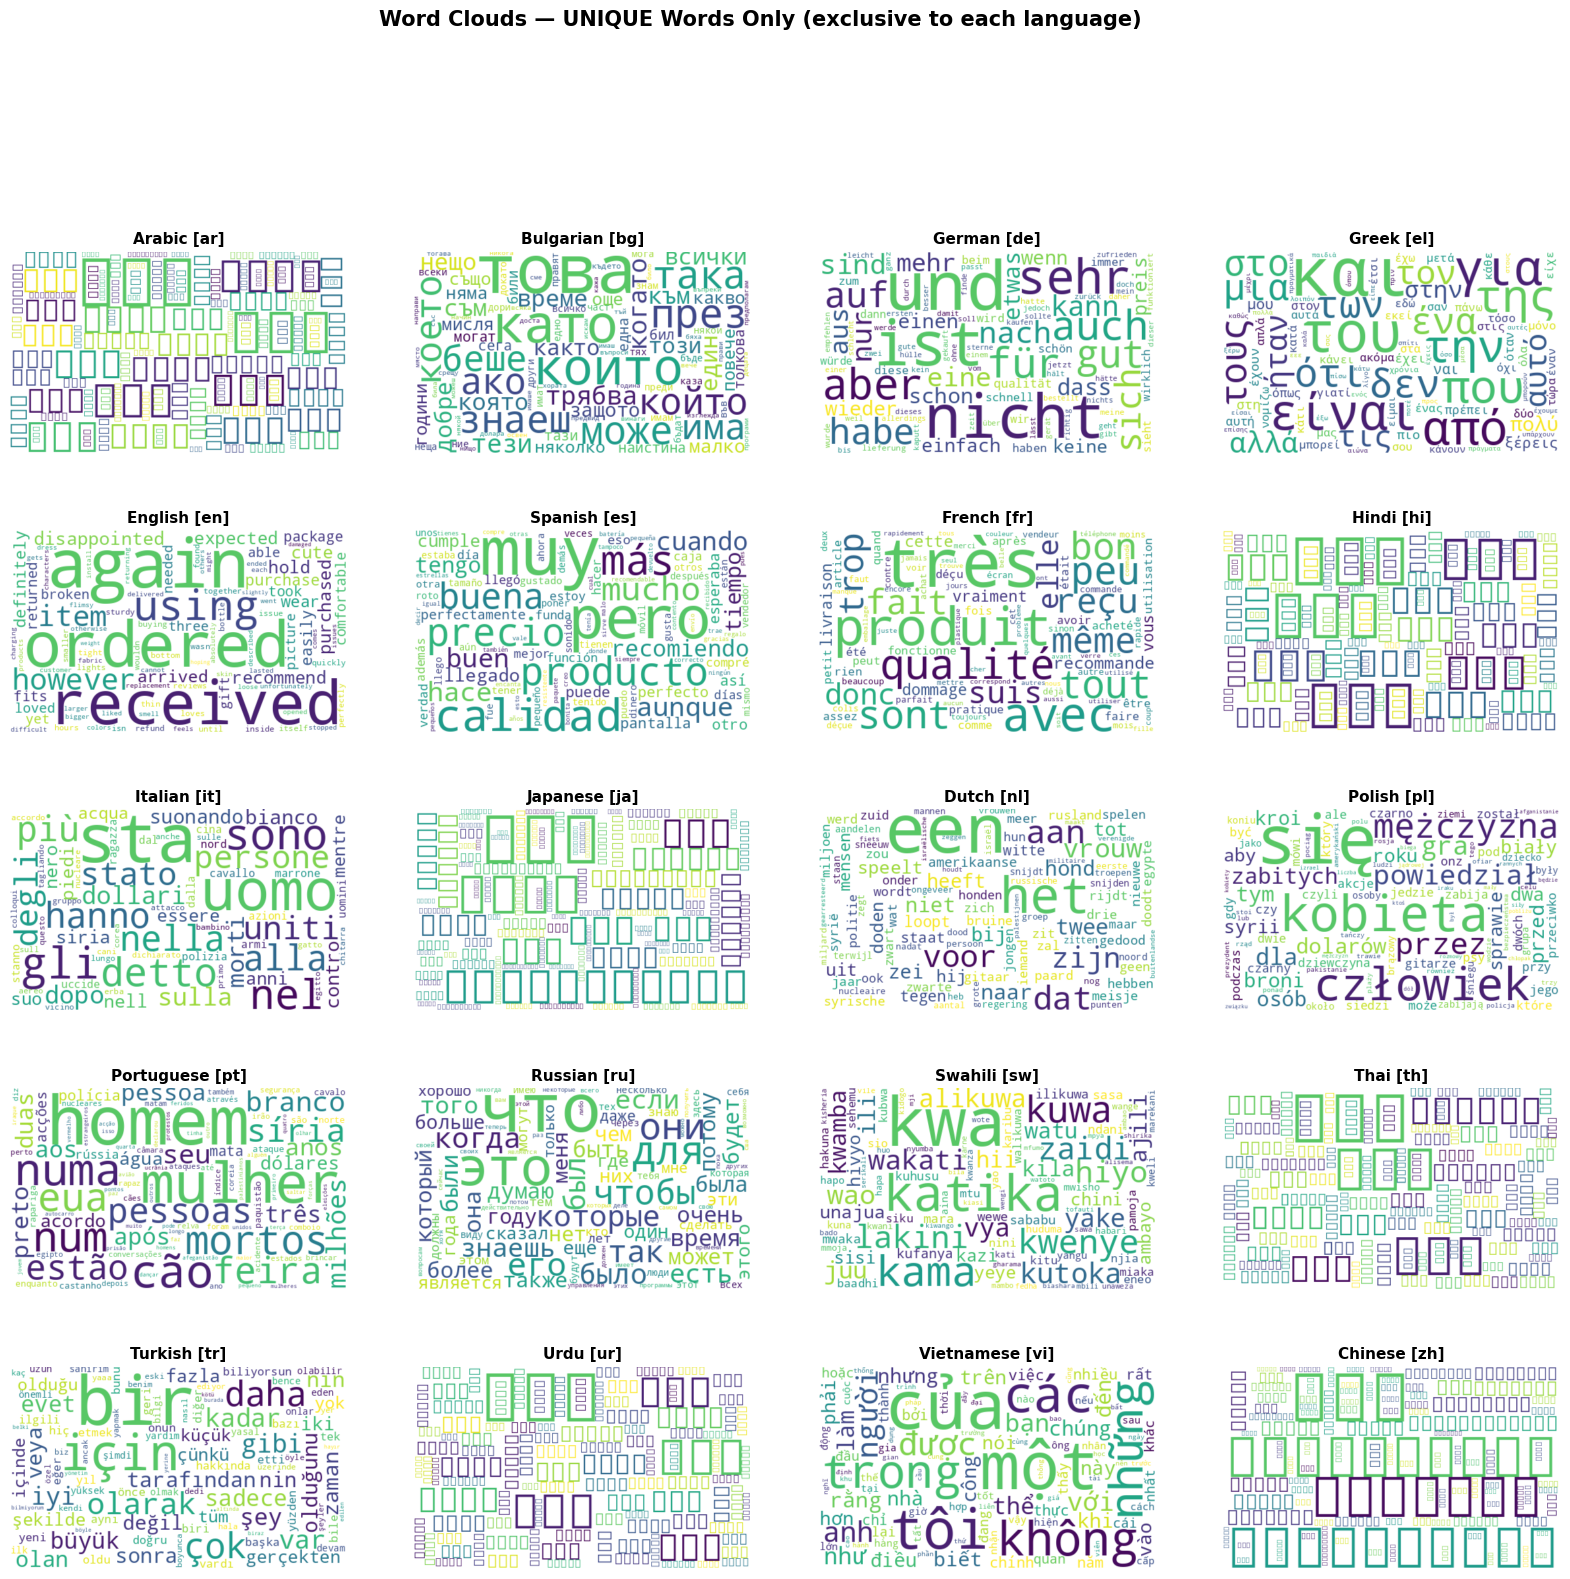

In [140]:
fig, axes = plt.subplots(n_rows_wc, n_cols_wc,figsize=(n_cols_wc * 5, n_rows_wc * 3.5))
axes = axes.flatten()
for ax, lang in zip(axes, classes):
    texts= train_df[train_df['labels'] == lang]['text'].tolist()
    tokens= re.findall(r'\b\w{3,}\b', ' '.join(texts).lower())
    cnt= Counter(tokens)
    unique_cnt = {w: c for w, c in cnt.items() if word_lang_count.get(w, 99) == 1}
    if len(unique_cnt) < 5:
        ax.text(0.5, 0.5, '(too few unique words)',ha='center', va='center', transform=ax.transAxes,fontsize=10, color='gray')
        ax.axis('off')
        ax.set_title(f"{LANG_NAMES[lang]} [{lang}]", fontweight='bold', fontsize=11)
        continue

    wc = WordCloud(
        width=500, height=300,
        background_color='white',
        max_words=100,
        prefer_horizontal=0.85,
        collocations=False,
        min_font_size=8, max_font_size=100,
        random_state=42,
    ).generate_from_frequencies(unique_cnt)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f"{LANG_NAMES[lang]} [{lang}]", fontweight='bold', fontsize=11, pad=6)

for ax in axes[len(classes):]:
    ax.set_visible(False)

plt.suptitle('Word Clouds — UNIQUE Words Only (exclusive to each language)',
             fontsize=15, fontweight='bold', y=1.01)
print('✅ These are the words the model relies on most for discrimination.')

## 6. EDA — Language Similarity (Vocabulary Overlap)

Top 10 most similar language pairs (hardest to distinguish):
  Hindi          ↔ Vietnamese      Jaccard=0.1780
  Swahili        ↔ Vietnamese      Jaccard=0.1744
  Thai           ↔ Vietnamese      Jaccard=0.1673
  Italian        ↔ Portuguese      Jaccard=0.1477
  Hindi          ↔ Thai            Jaccard=0.1396
  Italian        ↔ Dutch           Jaccard=0.1257
  Dutch          ↔ Portuguese      Jaccard=0.1171
  Turkish        ↔ Vietnamese      Jaccard=0.1153
  Swahili        ↔ Thai            Jaccard=0.1105
  Hindi          ↔ Swahili         Jaccard=0.1034


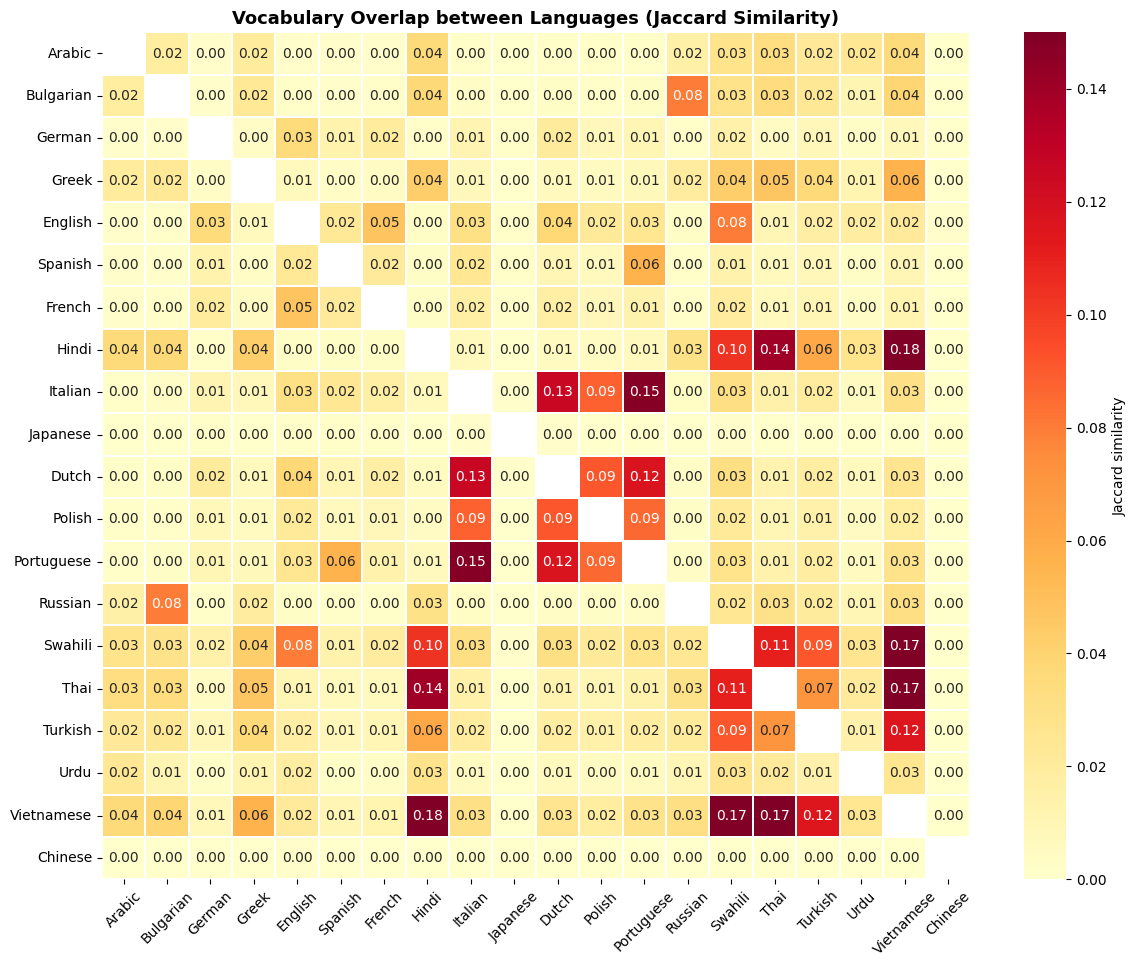

In [141]:
def jaccard(set_a, set_b):
    inter = len(set_a & set_b)
    union = len(set_a | set_b)
    return inter / union if union > 0 else 0.0

n = len(classes)
sim_matrix = np.zeros((n, n))
for i, la in enumerate(classes):
    for j, lb in enumerate(classes):
        sim_matrix[i, j] = jaccard(lang_vocabs[la], lang_vocabs[lb])

sim_df = pd.DataFrame(sim_matrix, index=class_names, columns=class_names)

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.eye(n, dtype=bool)
sns.heatmap(sim_df, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.3, ax=ax, mask=mask,
            vmin=0, vmax=0.15,
            cbar_kws={"label": "Jaccard similarity"})
ax.set_title("Vocabulary Overlap between Languages (Jaccard Similarity)",
             fontsize=13, fontweight="bold")
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)
pairs = []
for i in range(n):
    for j in range(i+1, n):
        pairs.append((class_names[i], class_names[j], sim_matrix[i,j]))
pairs.sort(key=lambda x: -x[2])
print("Top 10 most similar language pairs (hardest to distinguish):")
for la, lb, score in pairs[:10]:
    print(f"  {la:<14} ↔ {lb:<14}  Jaccard={score:.4f}")


## 7. Training and Evaluating Word vs Character Models

In [142]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)
word_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            analyzer="word",
            ngram_range=(1, 2),
            max_features=100_000,
            sublinear_tf=True,
            min_df=2,
            lowercase=True,
        ),
    ),
    (
        "clf",
        CalibratedClassifierCV(
            LinearSVC(
                C=1.0,
                max_iter=2000,
                dual=True,
                random_state=42,
            ),
            cv=3,
            method="sigmoid",
        ),
    ),
])
char_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(2, 4),
            max_features=100_000,
            sublinear_tf=True,
            min_df=2,
            lowercase=True,
        ),
    ),
    (
        "clf",
        CalibratedClassifierCV(
            LinearSVC(
                C=1.0,
                max_iter=2000,
                dual=True,
                random_state=42,
            ),
            cv=3,
            method="sigmoid",
        ),
    ),
])
word_pipeline.fit(x_train, y_train)
char_pipeline.fit(x_train, y_train)
word_pred = word_pipeline.predict(x_test)
char_pred = char_pipeline.predict(x_test)

In [143]:
def evaluate_model(name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted"
    )

    print(f"\n{'='*50}")
    print(name)
    print(f"{'='*50}")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

In [144]:
evaluate_model("WORD TF-IDF MODEL",y_test,word_pred)
evaluate_model("CHARACTER TF-IDF MODEL",y_test,char_pred)


WORD TF-IDF MODEL
Accuracy : 0.9429
Precision: 0.9658
Recall   : 0.9429
F1 Score : 0.9377

Classification Report:
              precision    recall  f1-score   support

          ar       1.00      0.99      0.99       500
          bg       0.99      0.99      0.99       500
          de       1.00      1.00      1.00       500
          el       1.00      1.00      1.00       500
          en       0.99      1.00      1.00       500
          es       0.98      0.99      0.99       500
          fr       1.00      1.00      1.00       500
          hi       1.00      0.96      0.98       500
          it       0.99      0.98      0.98       500
          ja       0.50      0.99      0.67       500
          nl       1.00      0.99      0.99       500
          pl       0.98      0.97      0.97       500
          pt       0.99      0.98      0.98       500
          ru       0.99      0.98      0.98       500
          sw       0.99      0.99      0.99       500
          th       1

Text(0.5, 0.98, 'Confusion Matrices — Test Set  (Accuracy: 99.57%)')

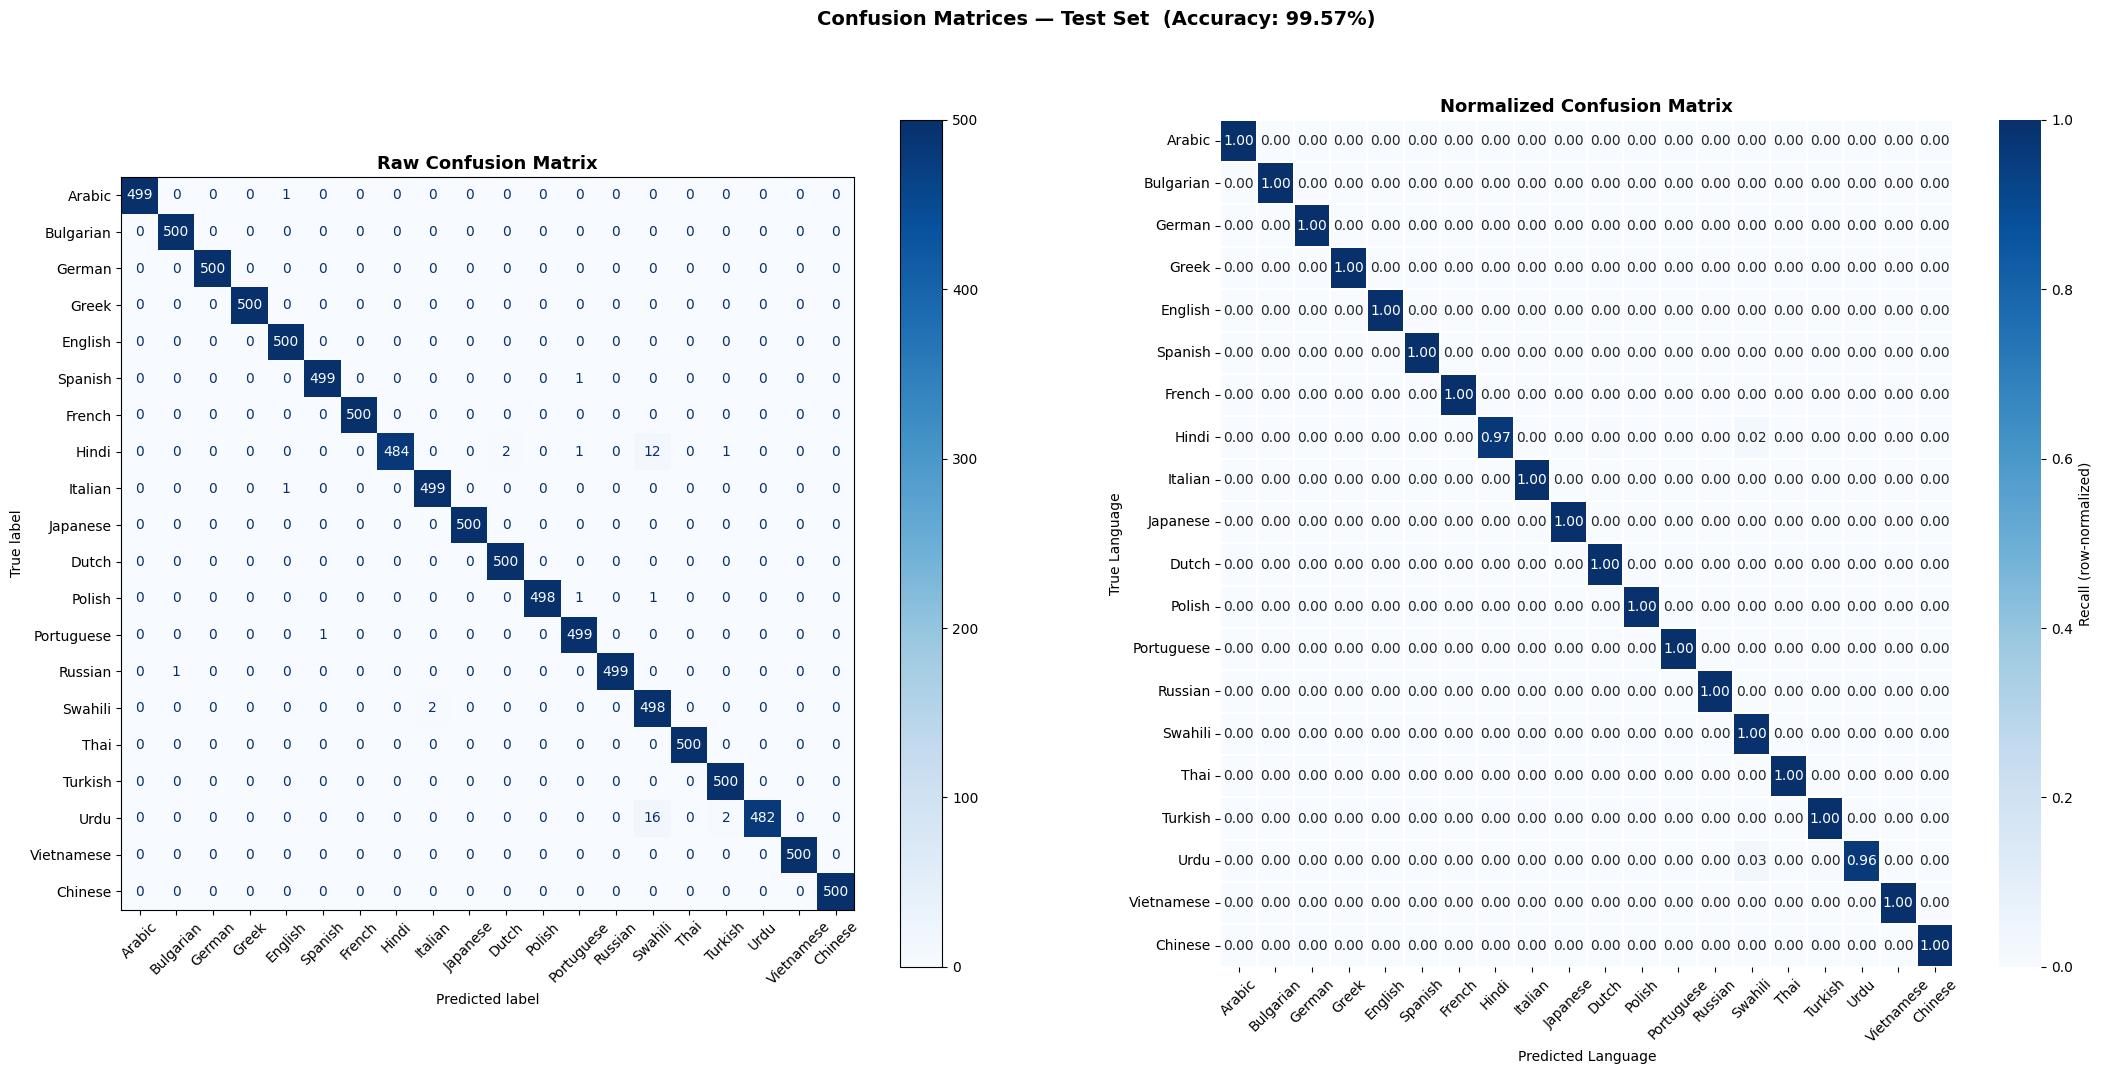

In [145]:
cm= confusion_matrix(y_test, char_pred, labels=classes)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(26, 11))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=axes[0], colorbar=True, cmap="Blues", xticks_rotation=45)
axes[0].set_title("Raw Confusion Matrix", fontsize=13, fontweight="bold")
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.3, ax=axes[1], vmin=0, vmax=1,
            cbar_kws={"label": "Recall (row-normalized)"})
axes[1].set_title("Normalized Confusion Matrix", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Predicted Language")
axes[1].set_ylabel("True Language")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle(f"Confusion Matrices — Test Set  (Accuracy: {test_acc*100:.2f}%)",
             fontsize=14, fontweight="bold")


## 8. Combining Word and Character Features for Language Classification

In [146]:
from sklearn.pipeline import FeatureUnion, Pipeline


In [147]:
word_tfidf = TfidfVectorizer(
    analyzer      = "word",
    ngram_range   = (1, 2),
    max_features  = 100_000,
    sublinear_tf  = True,
    min_df        = 2,
    strip_accents = None,
    lowercase     = True,
)

char_tfidf = TfidfVectorizer(
    analyzer     = "char_wb",
    ngram_range  = (2, 4),
    max_features = 200_000,
    sublinear_tf = True,
    min_df       = 2,
    lowercase    = True,
)

feature_union = FeatureUnion([
    ("word_tfidf", word_tfidf),
    ("char_tfidf", char_tfidf),
])

base_svc= LinearSVC(C=1.0, max_iter=2000, dual=True, random_state=42)
calibrated= CalibratedClassifierCV(base_svc, cv=3, method="sigmoid")
pipeline = Pipeline([
    ("features",   feature_union),
    ("classifier", calibrated),
])

print("✅ Pipeline defined")
print()
print(pipeline)

✅ Pipeline defined

Pipeline(steps=[('features',
                 FeatureUnion(transformer_list=[('word_tfidf',
                                                 TfidfVectorizer(max_features=100000,
                                                                 min_df=2,
                                                                 ngram_range=(1,
                                                                              2),
                                                                 sublinear_tf=True)),
                                                ('char_tfidf',
                                                 TfidfVectorizer(analyzer='char_wb',
                                                                 max_features=200000,
                                                                 min_df=2,
                                                                 ngram_range=(2,
                                                                              4),
      

In [148]:
print("  Training Language Detection Pipeline")
t0 = time.time()
pipeline.fit(x_train, y_train)
train_time = time.time() - t0
print(f"\ Training complete in {train_time:.1f}s")
train_preds = pipeline.predict(x_train)
train_acc   = accuracy_score(y_train, train_preds)
print(f"   Train accuracy : {train_acc*100:.4f}%")
word_vocab = len(word_tfidf.vocabulary_)
char_vocab = len(char_tfidf.vocabulary_)
print(f"   Word n-gram features : {word_vocab:,}")
print(f"   Char n-gram features : {char_vocab:,}")
print(f"   Total features       : {word_vocab + char_vocab:,}")

  Training Language Detection Pipeline
\ Training complete in 96.0s
   Train accuracy : 99.9800%
   Word n-gram features : 100,000
   Char n-gram features : 200,000
   Total features       : 300,000


In [149]:
val_preds  = pipeline.predict(x_val)
test_preds = pipeline.predict(x_test)
val_acc  = accuracy_score(y_val,  val_preds)
test_acc = accuracy_score(y_test, test_preds)
print(f"  Train      Accuracy : {train_acc*100:.4f}%")
print(f"  Validation Accuracy : {val_acc*100:.4f}%")
print(f"  Test       Accuracy : {test_acc*100:.4f}%")

  Train      Accuracy : 99.9800%
  Validation Accuracy : 99.5500%
  Test       Accuracy : 99.5700%


In [150]:
print("\n=== Classification Report (Test Set) ===\n")
report_dict = classification_report(
    y_test, test_preds, target_names=classes,
    output_dict=True, zero_division=0
)
print(classification_report(y_test, test_preds, target_names=class_names, digits=4))


=== Classification Report (Test Set) ===

              precision    recall  f1-score   support

      Arabic     1.0000    0.9980    0.9990       500
   Bulgarian     0.9980    1.0000    0.9990       500
      German     1.0000    1.0000    1.0000       500
       Greek     1.0000    1.0000    1.0000       500
     English     0.9980    1.0000    0.9990       500
     Spanish     0.9960    0.9980    0.9970       500
      French     1.0000    1.0000    1.0000       500
       Hindi     1.0000    0.9680    0.9837       500
     Italian     0.9960    0.9960    0.9960       500
    Japanese     1.0000    1.0000    1.0000       500
       Dutch     0.9960    1.0000    0.9980       500
      Polish     1.0000    0.9980    0.9990       500
  Portuguese     0.9940    0.9960    0.9950       500
     Russian     1.0000    0.9980    0.9990       500
     Swahili     0.9596    0.9980    0.9784       500
        Thai     1.0000    1.0000    1.0000       500
     Turkish     0.9804    1.0000    0

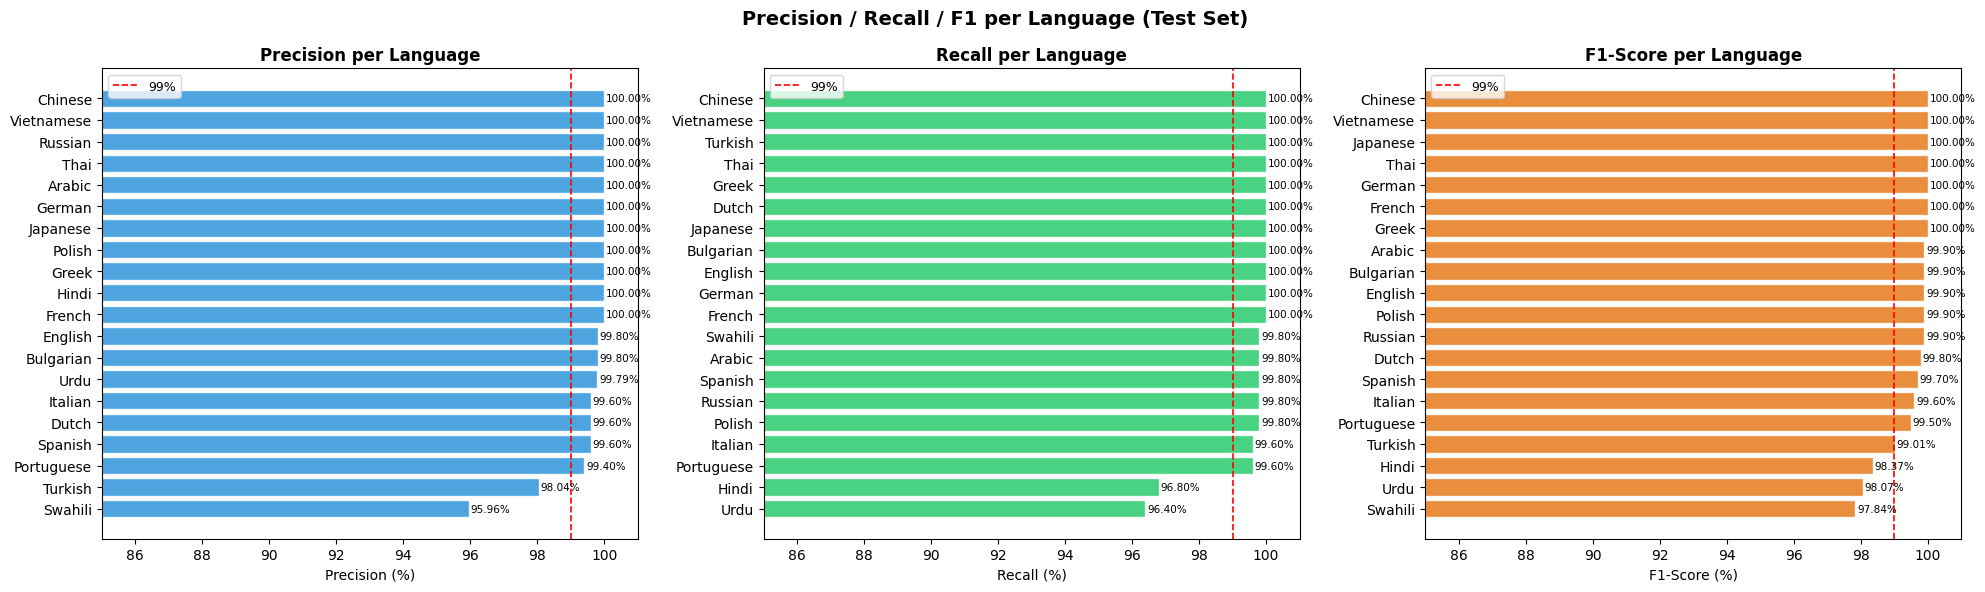

In [151]:
metrics_data = []
for lang_code, lang_name in zip(classes, class_names):
    d = report_dict[lang_code]
    metrics_data.append({
        "Language":  lang_name,
        "Precision": round(d["precision"]*100, 2),
        "Recall":    round(d["recall"]*100, 2),
        "F1-Score":  round(d["f1-score"]*100, 2),
        "Support":   d["support"],
    })
metrics_df = pd.DataFrame(metrics_data).set_index("Language")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, col, color in zip(axes,
                           ["Precision", "Recall", "F1-Score"],
                           ["#3498db", "#2ecc71", "#e67e22"]):
    vals = metrics_df[col].sort_values()
    ax.barh(vals.index, vals.values, color=color, edgecolor="white", alpha=0.88)
    ax.axvline(99, color="red", linestyle="--", linewidth=1.2, label="99%")
    ax.set_xlim(85, 101)
    ax.set_title(f"{col} per Language", fontweight="bold", fontsize=12)
    ax.set_xlabel(f"{col} (%)")
    ax.legend(fontsize=9)
    for i, (v, name) in enumerate(zip(vals.values, vals.index)):
        ax.text(v + 0.05, i, f"{v:.2f}%", va="center", fontsize=7.5)

plt.suptitle("Precision / Recall / F1 per Language (Test Set)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_metrics_per_lang.png", bbox_inches="tight")
plt.show()

Text(0.5, 0.98, 'Confusion Matrices — Test Set  (Accuracy: 99.57%)')

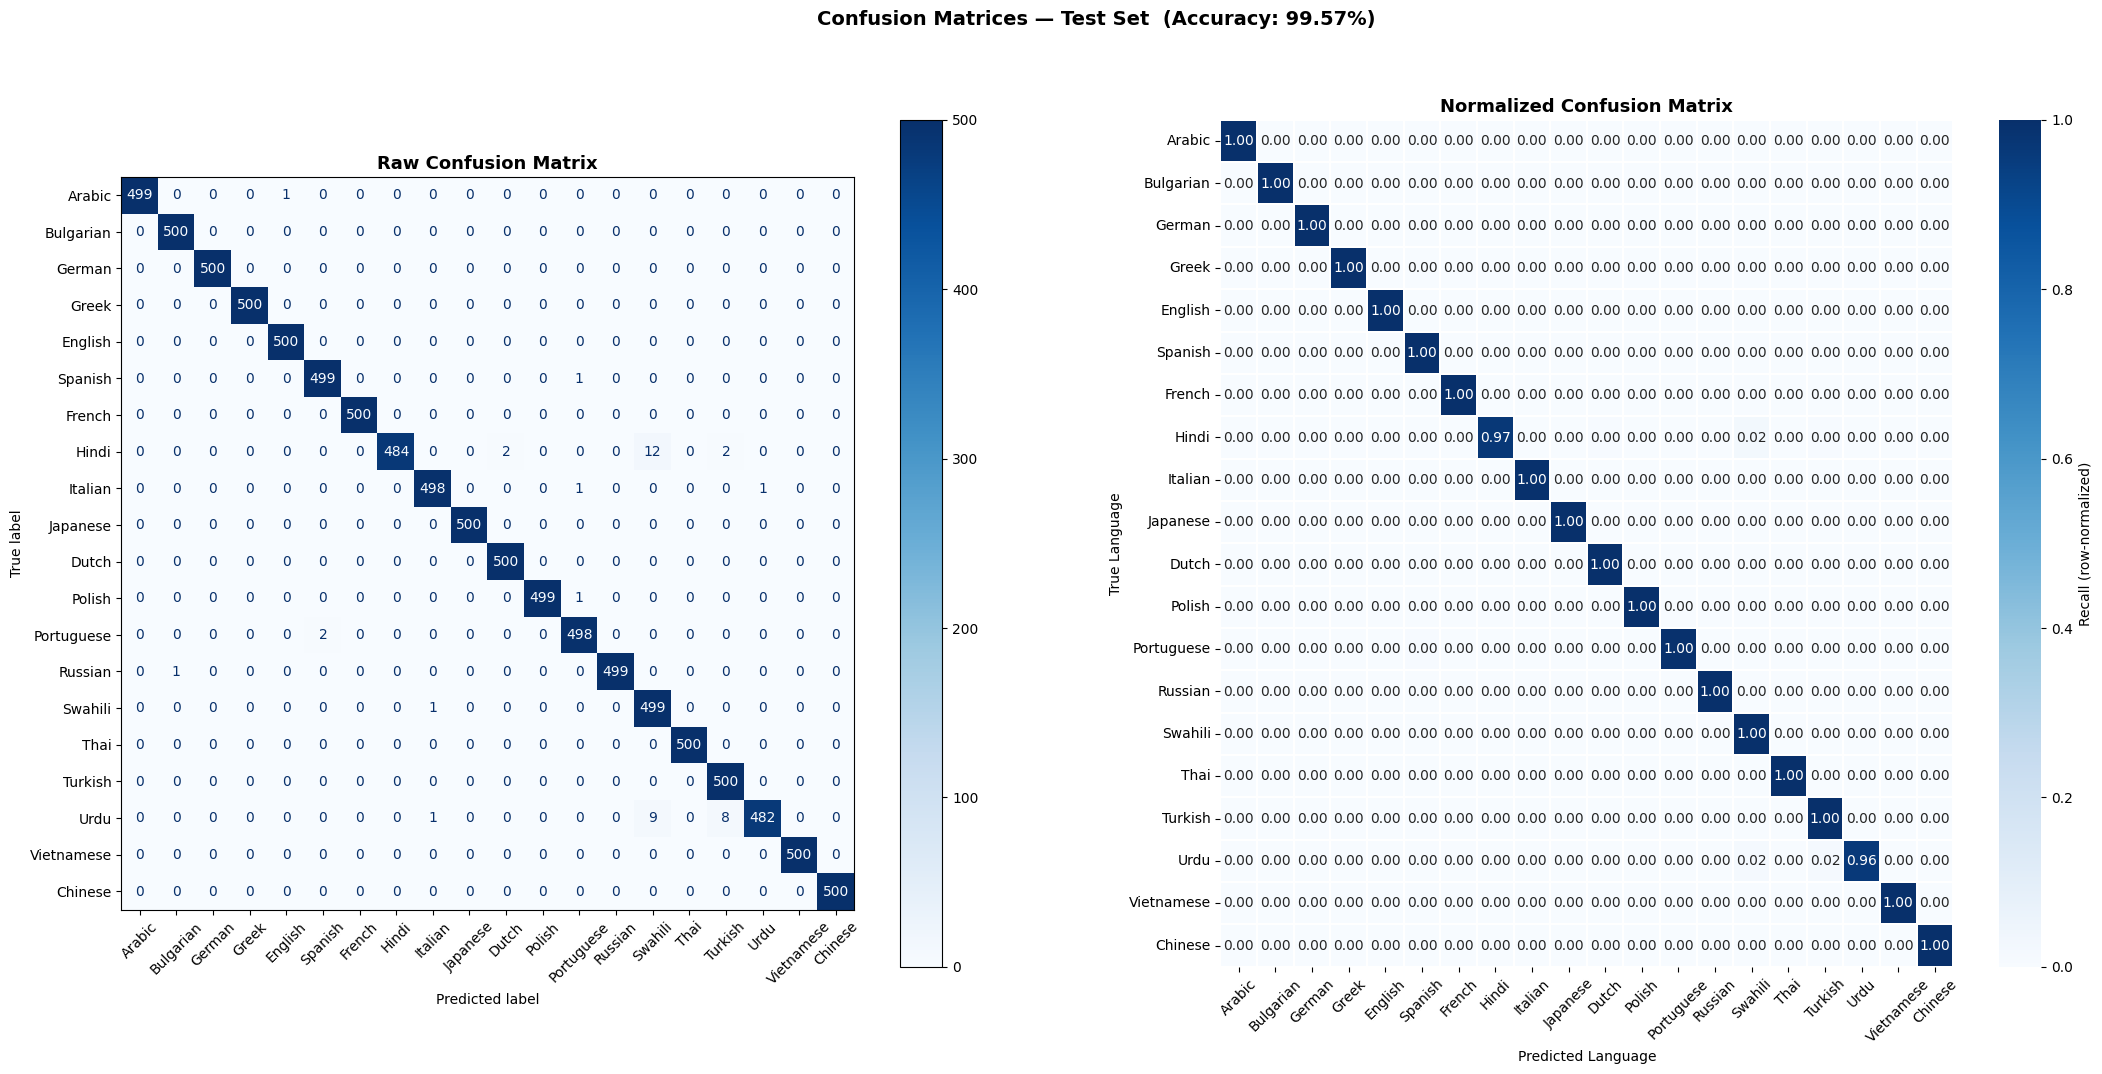

In [152]:
cm= confusion_matrix(y_test, test_preds, labels=classes)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(26, 11))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=axes[0], colorbar=True, cmap="Blues", xticks_rotation=45)
axes[0].set_title("Raw Confusion Matrix", fontsize=13, fontweight="bold")
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.3, ax=axes[1], vmin=0, vmax=1,
            cbar_kws={"label": "Recall (row-normalized)"})
axes[1].set_title("Normalized Confusion Matrix", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Predicted Language")
axes[1].set_ylabel("True Language")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle(f"Confusion Matrices — Test Set  (Accuracy: {test_acc*100:.2f}%)",
             fontsize=14, fontweight="bold")


## 9. Error Analysis of the Character TF-IDF Model

Total errors : 43 / 10000
Error rate   : 0.430%



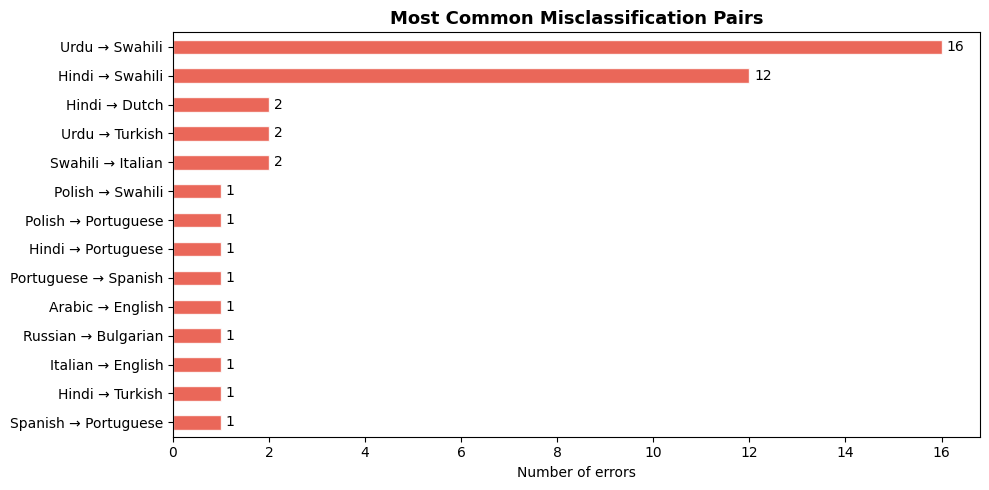


=== Sample Misclassified Texts ===

  True: Hindi          | Pred: Swahili        | un jaanavaron ke maamale mein, jo apane maalikon dvaara theek nahin kiye jaate hain, aapki...
  True: Urdu           | Pred: Swahili        | Ise ghor kiya jye kai postal cost ka asarfrance mai zyada hah
  True: Hindi          | Pred: Swahili        | Haznawi (Flight 93) aur Wail al Shehri (Flight 11)  June 8, 2001 ko vahi purani route se L...
  True: Urdu           | Pred: Swahili        | newsweek ne bataya kai pro wrestling apne madahoon ko dilchasp rekhe kai lye kis had tak j...
  True: Urdu           | Pred: Swahili        | hamari biography ki trha aik khas badal, shayad tayar hota hah jiske nateje mai complex sp...
  True: Spanish        | Pred: Portuguese     | exactamente como descrito
  True: Urdu           | Pred: Swahili        | To mai gaya, mai Washington D.C. gaya aur mai direct nahi gaya, aur unho ne mjhe orders di...
  True: Urdu           | Pred: Swahili        | aur wo hoosh me aya, 

In [153]:
test_df_copy = test_df.copy()
test_df_copy["predicted"] = char_pred
test_df_copy["correct"]   = test_df_copy["labels"] == test_df_copy["predicted"]

errors = test_df_copy[~test_df_copy["correct"]].copy()
print(f"Total errors : {len(errors)} / {len(test_df_copy)}")
print(f"Error rate   : {len(errors)/len(test_df_copy)*100:.3f}%\n")

if len(errors) > 0:
    errors["pair"] = errors["labels"] + " → " + errors["predicted"]
    top_pairs = errors["pair"].value_counts().head(15)
    top_pairs.index = [
        f"{LANG_NAMES[p.split(' → ')[0]]} → {LANG_NAMES[p.split(' → ')[1]]}"
        for p in top_pairs.index
    ]

    fig, ax = plt.subplots(figsize=(10, 5))
    top_pairs.plot(kind="barh", ax=ax, color="#e74c3c", edgecolor="white", alpha=0.85)
    ax.set_title("Most Common Misclassification Pairs", fontweight="bold", fontsize=13)
    ax.set_xlabel("Number of errors")
    ax.invert_yaxis()
    for i, v in enumerate(top_pairs.values):
        ax.text(v + 0.1, i, str(v), va="center")
    plt.tight_layout()
    plt.savefig("fig_error_pairs.png", bbox_inches="tight")
    plt.show()

    print("\n=== Sample Misclassified Texts ===\n")
    sample = errors.sample(min(8, len(errors)), random_state=42)
    for _, row in sample.iterrows():
        true_n = LANG_NAMES[row["labels"]]
        pred_n = LANG_NAMES[row["predicted"]]
        text_p = row["text"][:90] + ("..." if len(row["text"]) > 90 else "")
        print(f"  True: {true_n:<14} | Pred: {pred_n:<14} | {text_p}")
else:
    print(" Zero errors on test set!")

## 10. Character n-gram Importance Visualization


In [154]:
char_pipeline.fit(x_train, y_train)

internal_svc = char_pipeline.named_steps["clf"].calibrated_classifiers_[0].estimator
char_feats = char_pipeline.named_steps["tfidf"].get_feature_names_out()
classes = list(internal_svc.classes_)

Text(0.5, 0.98, 'Top 15 Character n-grams per Language')

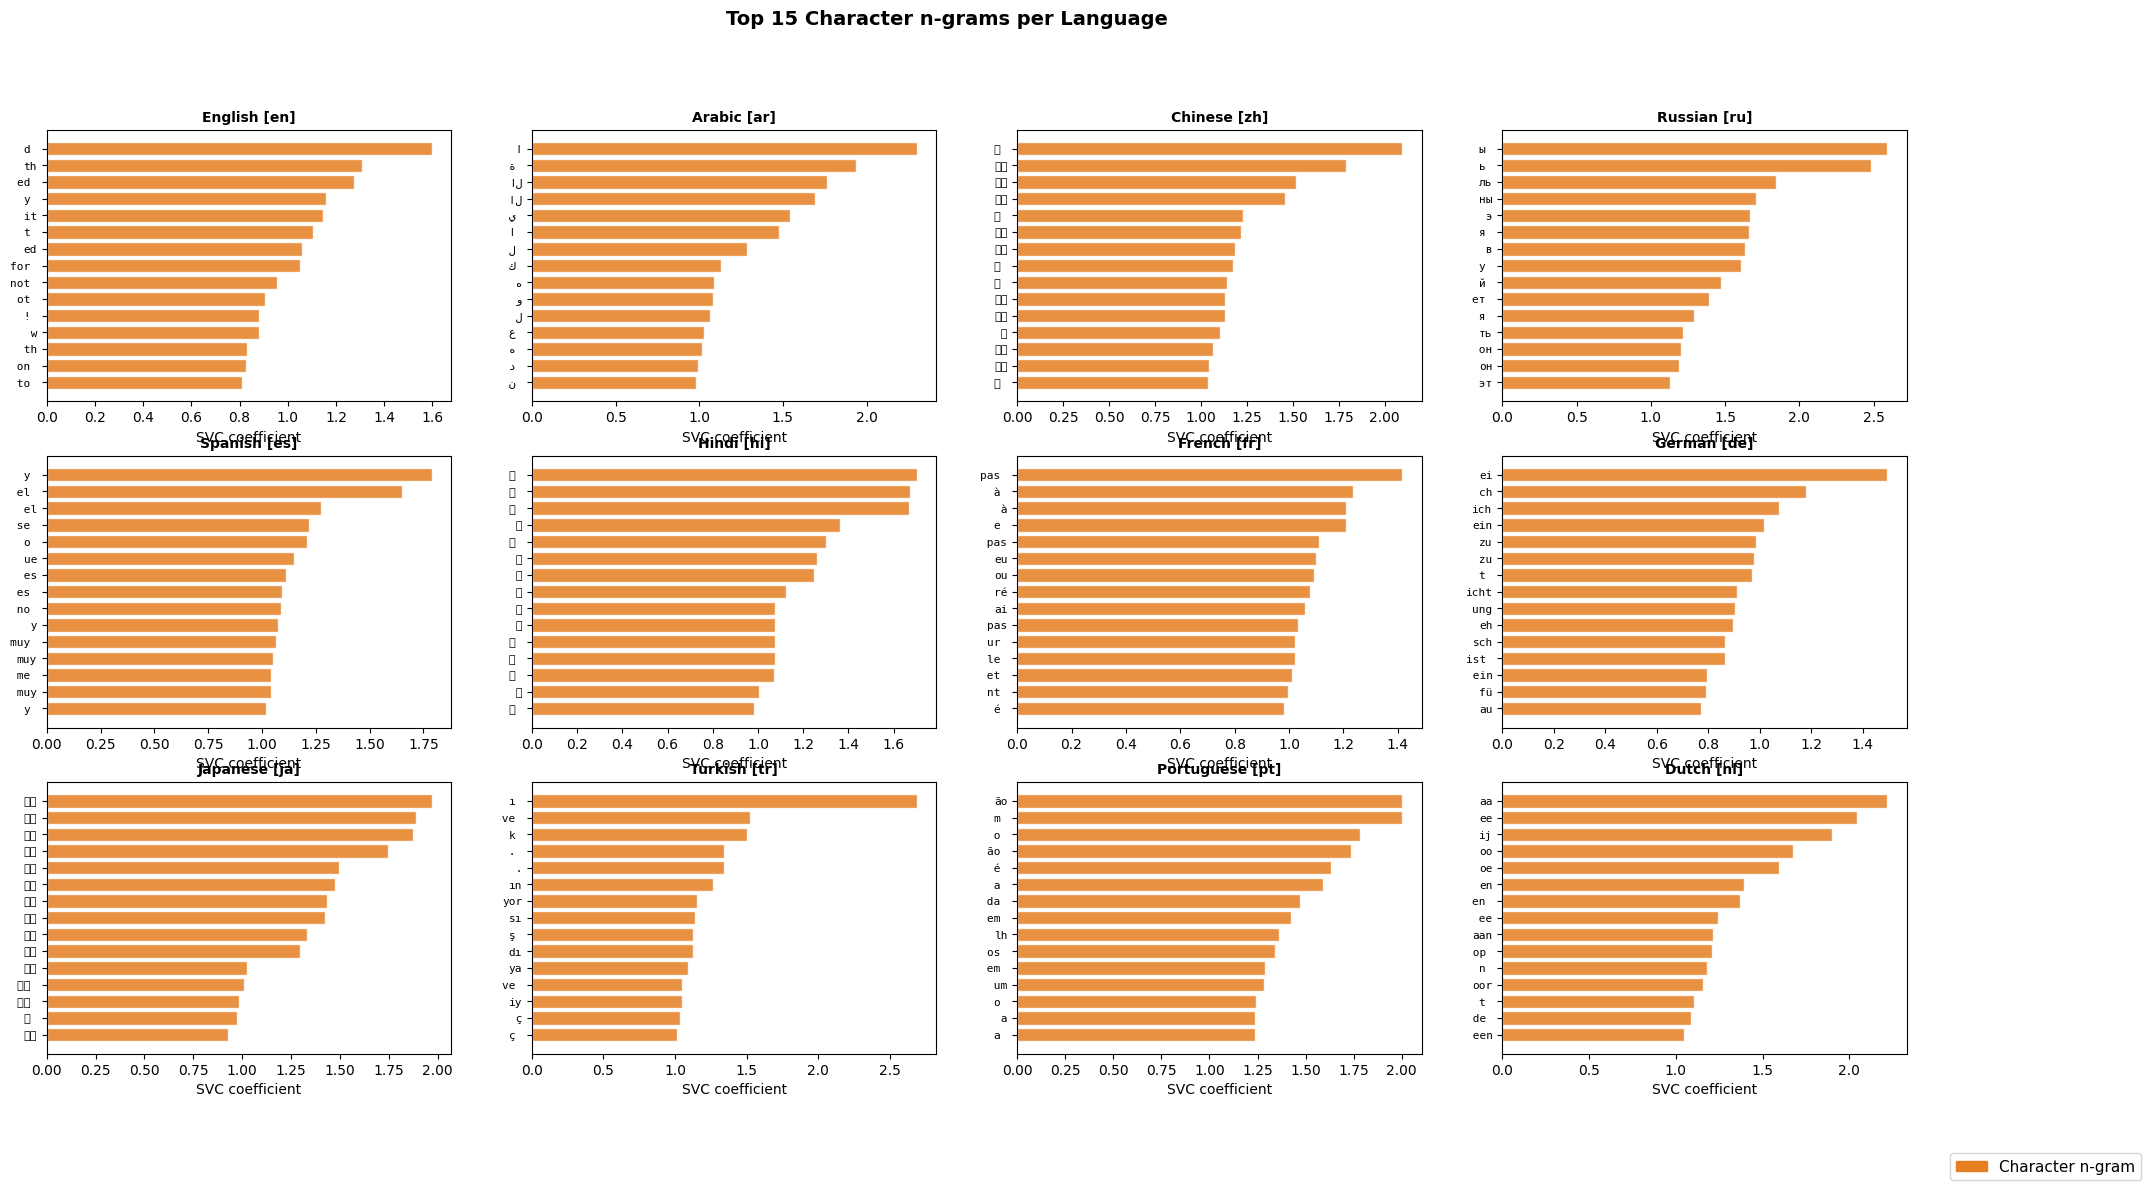

In [155]:
import matplotlib.patches as mpatches

display_langs = ["en", "ar", "zh", "ru", "es", "hi",
                 "fr", "de", "ja", "tr", "pt", "nl"]
n_cols = 4
n_rows = (len(display_langs) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(24, n_rows * 4))
axes = axes.flatten()
for ax, lang in zip(axes, display_langs):
    class_idx = classes.index(lang)
    coef = internal_svc.coef_[class_idx]
    top_idx = coef.argsort()[::-1][:15]
    top_feats = [char_feats[i] for i in top_idx]
    top_scores = coef[top_idx]
    y_pos = range(len(top_feats))
    ax.barh(
        list(y_pos),
        list(top_scores)[::-1],
        color="#e67e22",
        edgecolor="white",
        alpha=0.85
    )
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(
        list(top_feats)[::-1],
        fontsize=8,
        fontfamily="monospace"
    )
    ax.set_title(
        f"{LANG_NAMES[lang]} [{lang}]",
        fontsize=10,
        fontweight="bold"
    )
    ax.set_xlabel("SVC coefficient")
for ax in axes[len(display_langs):]:
    ax.set_visible(False)
orange_patch = mpatches.Patch(
    color="#e67e22",
    label="Character n-gram"
)
fig.legend(
    handles=[orange_patch],
    loc="lower right",
    fontsize=11
)
plt.suptitle(
    "Top 15 Character n-grams per Language",
    fontsize=14,
    fontweight="bold"
)


## 11. Compare Word, Character, and Combined models using test predictions and correctness counts.

In [156]:
def detect_language(model, text, model_name, top_k=3):

    proba = model.predict_proba([text])[0]
    pred = model.predict([text])[0]

    top_idx = proba.argsort()[::-1][:top_k]

    print(f"\n{model_name}")
    print("-" * 50)
    print(f"Prediction: {LANG_NAMES[pred]} [{pred}]")

    for idx in top_idx:
        bar = "█" * int(proba[idx] * 40)

        print(
            f"{LANG_NAMES[classes[idx]]:<15}"
            f"[{classes[idx]}] "
            f"{proba[idx]*100:6.2f}% "
            f"{bar}"
        )

    return pred

In [157]:
test_sentences = [
    ("en", "I have been feeling very anxious and overwhelmed lately."),
    ("fr", "Je me sens déprimé et je ne sais pas quoi faire."),
    ("ar", "أشعر بالقلق الشديد ولا أستطيع النوم."),
    ("zh", "我最近感到非常焦虑，睡眠也很差。"),
    ("ru", "Я не могу справиться со своей тревогой и депрессией."),
    ("hi", "मुझे बहुत चिंता हो रही है और मैं सो नहीं पा रहा।"),
    ("de", "Ich fühle mich sehr gestresst und weiß nicht mehr weiter."),
    ("ja", "最近、とても不安でストレスを感じています。"),
]

In [158]:
print("=" * 80)
print("LANGUAGE DETECTION COMPARISON")
print("=" * 80)

word_correct = 0
char_correct = 0
combined_correct = 0

for true_lang, sentence in test_sentences:

    print("\n" + "=" * 80)
    print(f"TEXT: {sentence}")
    print(f"TRUE LANGUAGE: {LANG_NAMES[true_lang]} [{true_lang}]")
    print("=" * 80)

    pred_word = detect_language(
        word_pipeline,
        sentence,
        "WORD TF-IDF MODEL"
    )

    pred_char = detect_language(
        char_pipeline,
        sentence,
        "CHARACTER TF-IDF MODEL"
    )

    pred_combined = detect_language(
        pipeline,
        sentence,
        "WORD + CHARACTER MODEL"
    )

    if pred_word == true_lang:
        word_correct += 1

    if pred_char == true_lang:
        char_correct += 1

    if pred_combined == true_lang:
        combined_correct += 1

LANGUAGE DETECTION COMPARISON

TEXT: I have been feeling very anxious and overwhelmed lately.
TRUE LANGUAGE: English [en]

WORD TF-IDF MODEL
--------------------------------------------------
Prediction: English [en]
English        [en]  98.03% ███████████████████████████████████████
Urdu           [ur]   0.73% 
Swahili        [sw]   0.30% 

CHARACTER TF-IDF MODEL
--------------------------------------------------
Prediction: English [en]
English        [en]  70.71% ████████████████████████████
Dutch          [nl]  29.03% ███████████
Urdu           [ur]   0.11% 

WORD + CHARACTER MODEL
--------------------------------------------------
Prediction: English [en]
English        [en]  97.72% ███████████████████████████████████████
Dutch          [nl]   1.62% 
Urdu           [ur]   0.39% 

TEXT: Je me sens déprimé et je ne sais pas quoi faire.
TRUE LANGUAGE: French [fr]

WORD TF-IDF MODEL
--------------------------------------------------
Prediction: French [fr]
French         [fr]  98.13% 

The **Character TF-IDF + LinearSVC** model was selected as the final language detection model because it achieved **the same accuracy** as the combined Word + Character model while being **more efficient**.

### Key Reasons
- Same overall accuracy as the combined model.
- Faster prediction and lower memory usage.
- Simpler feature representation and easier maintenance.
- Better captures language-specific patterns through character n-grams.
- More robust for short texts, unseen words, and different writing systems.

### Final Decision
The Character TF-IDF model provides the best balance between **accuracy, efficiency, and scalability**, making it the preferred choice for deployment.

## Save Model

In [159]:
import os

model_path = "language_detection_pipeline.pkl"
joblib.dump(char_pipeline, model_path)
size_mb = os.path.getsize(model_path) / (1024*1024)
print(f"✅ Pipeline saved to '{model_path}'  ({size_mb:.1f} MB)")

loaded= joblib.load(model_path)
check_acc= accuracy_score(y_test[:200], loaded.predict(x_test[:200]))
print(f"✅ Verified  (spot-check accuracy: {check_acc*100:.1f}%)")

✅ Pipeline saved to 'language_detection_pipeline.pkl'  (49.2 MB)
✅ Verified  (spot-check accuracy: 100.0%)
